<a href="https://colab.research.google.com/github/laraagasii/2311531002_HANIFAHLARAMAAGASI_ImageProcessing/blob/main/image_enchacement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def proses_citra_lengkap(image_path):
    # Membaca citra dalam grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Error: Gambar tidak ditemukan. Pastikan nama file benar!")
        return

    height, width = img.shape
    n_total_pixel = height * width

    # --- NORMALISASI HISTOGRAM ---
    hist_raw = np.zeros(256)
    for i in range(height):
        for j in range(width):
            intensity = img[i, j]
            hist_raw[intensity] += 1

    hist_norm = hist_raw / n_total_pixel

    # --- HISTOGRAM EQUALIZATION (MANUAL) ---
    cdf = np.zeros(256)
    cumulative_sum = 0
    for i in range(256):
        cumulative_sum += hist_norm[i]
        cdf[i] = cumulative_sum

    mapping_equalization = np.floor(cdf * 255).astype(np.uint8)

    img_equ = np.zeros_like(img)
    for i in range(height):
        for j in range(width):
            img_equ[i, j] = mapping_equalization[img[i, j]]

    # --- VISUALISASI HASIL ---
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('1. Citra Asli (Original)')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(img_equ, cmap='gray')
    plt.title('2. Citra Setelah Equalization')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.bar(range(256), hist_norm, color='gray', width=1.0)
    plt.title('Histogram Normalisasi (Sebelum)')
    plt.xlabel('Intensitas'); plt.ylabel('Peluang h(i)')

    hist_final = np.zeros(256)
    for i in range(height):
        for j in range(width):
            hist_final[img_equ[i, j]] += 1
    hist_final_norm = hist_final / n_total_pixel

    plt.subplot(2, 2, 4)
    plt.bar(range(256), hist_final_norm, color='blue', width=1.0)
    plt.title('Histogram Normalisasi (Sesudah)')
    plt.xlabel('Intensitas'); plt.ylabel('Peluang h(i)')

    plt.tight_layout()
    plt.show()

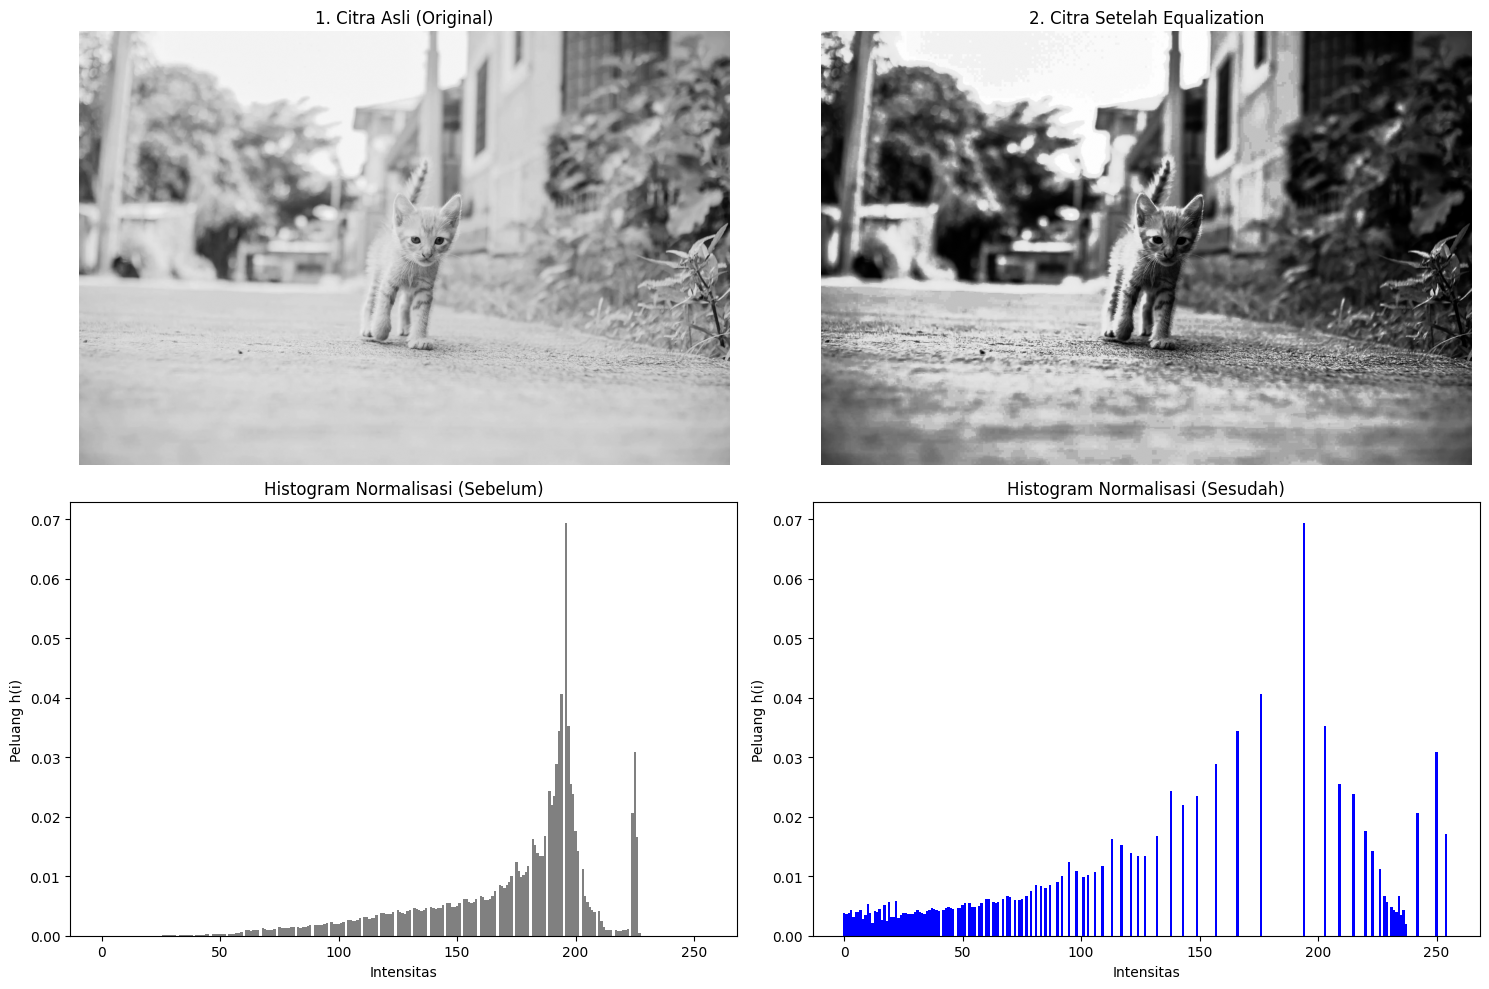

In [11]:
proses_citra_lengkap('image2.webp')